# Statistical costs: turn uncertainty into a price

When should a phase jump be explained as noise, and when should the model tolerate a discontinuity?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

A statistical cost assigns a price to each candidate integer correction.
In a quadratic prior model, write $C_e(k)=a_e(k-\mu_e)^2$, where $\mu_e$
is a predicted correction in turns and $a_e$ is inverse-variance-like curvature.
For $\mu=0.2$, candidate $k=0$ has residual $-0.2$ turns; $k=1$ has $0.8$.
At equal curvature, their costs are in the ratio $0.04:0.64$.

1. Estimate directional mean steps and uncertainty from supplied coherence.
2. Convert them into edge correction costs.
3. Solve the convex model under cycle constraints.
4. In deformation mode, optionally refine a nonconvex shelf model that makes
   some large discrepancies less costly; inspect its proof flag.

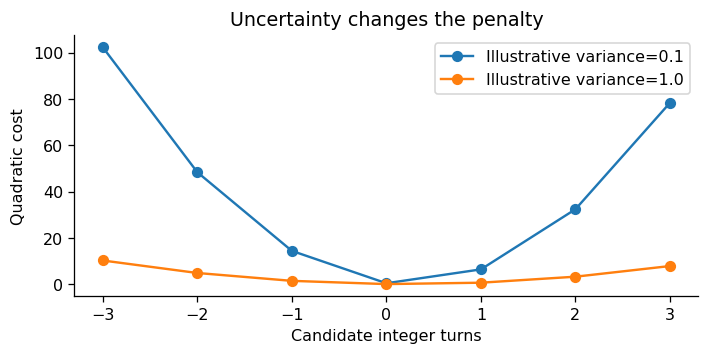

| k | Residual in turns | Cost at variance 1 |
|---|---|---|
| 0 | -0.2 | 0.04 |
| 1 | 0.8 | 0.64 |

In [2]:
k=np.arange(-3,4); mu=.2
fig,ax=plt.subplots(figsize=(7,3))
for variance in [.1,1.]: ax.plot(k,(k-mu)**2/variance,'o-',label=f'Illustrative variance={variance}')
ax.set(xlabel='Candidate integer turns',ylabel='Quadratic cost',title='Uncertainty changes the penalty'); ax.legend(); plt.show()
table(['k','Residual in turns','Cost at variance 1'],[(i,f'{i-mu:.1f}',f'{(i-mu)**2:.2f}') for i in [0,1]])

## 2 · Read the calculation

These curves illustrate a quadratic prior; the actual implementation estimates
its variance and mean through the documented sensor and box-average model.
Coherence is supplied data, not the same thing as the phase-only reliability
score. Calling a phase score coherence does not make it a calibrated measurement.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

StatCostInfo(backend='stat-costs-flow', costmode='smooth', shape=(18, 22), pixels=396, nodes=396, edges=752, cycles=357, residues=4, components=1, shelf_edges=0, masked_edges=0, max_jump=1, objective=72.34411134276239, initial_objective=72.34411134276239, sweeps=0, moves=0, proven=True, ncorrlooks=23.8, rho0=0.1946218487394958, defocorrthresh=0.23354621848739496)


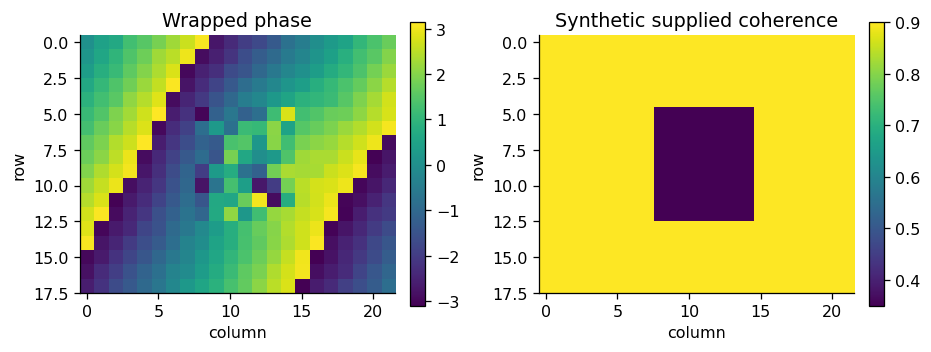

| Quantity | Measured value |
|---|---|
| Aligned RMSE (rad) | 0.411490 |
| Raw max wrapped difference from input (rad) | 0.000000 |

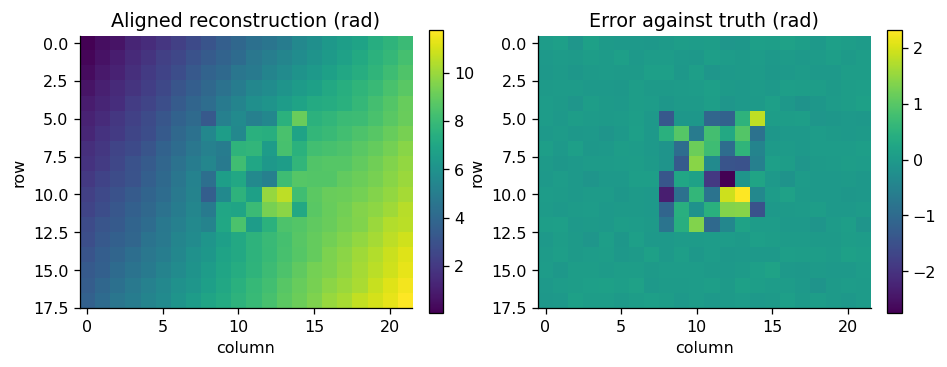

In [3]:
truth,phase,confidence=scene()
coherence=np.where(confidence<1,.35,.9)
params=pv.StatCostParams(kperpdpsi=3,kpardpsi=3)
u,info=pv.stat_cost_unwrap(phase,coherence,params=params,costmode='smooth',return_info=True)
print(info); images([phase,coherence],['Wrapped phase','Synthetic supplied coherence']); report(u,truth,phase)

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

In [4]:
rows=[]
for mode,shelf in [('smooth',False),('defo',False),('defo',True)]:
    value,info=pv.stat_cost_unwrap(phase,coherence,params=params,costmode=mode,shelf=shelf,return_info=True)
    rows.append([mode,shelf,info.proven,f'{pv.rmse_aligned(value,truth):.4f}'])
table(['Model','Shelf requested','Proven','Aligned RMSE'],rows)

| Model | Shelf requested | Proven | Aligned RMSE |
|---|---|---|---|
| smooth | False | True | 0.4115 |
| defo | False | True | 0.4115 |
| defo | True | False | 0.4115 |

## 5 · Interpretation and limits

The smooth convex solve and capped deformation refinement have different
objectives. A proof for the former does not transfer to the latter. Window sizes
must fit the directional gradient arrays; this small scene explicitly uses a
3-pixel window. This 2-D implementation is inspired by statistical network
models; it is not a call to an external SNAPHU executable and should not be
presented as a complete drop-in numerical reproduction of it.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`stat_costs.py`](../src/parvaneh/stat_costs.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.